# Laplace: box plots and sample paths

In [1]:
from pathlib import Path
import unicodedata

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import numpy as np


D = 20
CHANGE_TIME = 500
BOX_TIMES = (500, 510, 520, 530, 540)
N_RUNS = 200
N_PATHS = 200
PATH_HORIZON = 1000
M_FEATURES = 500
REF_SIZE = 500
BOX_SEED = 456 + 5_500_000 + 200_000 + 10_000 * D
PATH_SEED = 98_765 + 4_000_000 + 10_000 * D
LAMBDA0 = LAMBDA1 = 1 - 1e-3
ETA = 1e-2
LAMBDA_CLIP = (1e-3, 1 - 1e-3)

OUTPUT_DIR = Path.cwd() / "OKAFF_laplace_boxes_sample_paths"
BOX_DIR = OUTPUT_DIR / "prepost_boxes"
PATH_DIR = OUTPUT_DIR / "sample_paths"


LAPLACE_ALTERNATIVES = [
    ("laplace_scale_0p25", "Laplace(0,0.25)ᵈ", 0.0, 0.25),
    ("laplace_scale_4", "Laplace(-1,0.25)ᵈ", -1.0, 0.25),
    ("laplace_scale_0p5", "Laplace(0,0.5)ᵈ", 0.0, 0.5),
    ("laplace_scale_2", "Laplace(0,2)ᵈ", 0.0, 2.0),
    ("laplace_scale_3", "Laplace(-2,0.5)ᵈ", -2.0, 0.5),
    ("laplace_scale_5", "Laplace(3,2)ᵈ", 3.0, 2.0),
]
assert BOX_TIMES[0] == CHANGE_TIME and all(t > CHANGE_TIME for t in BOX_TIMES[1:])


In [2]:
class AdaptiveForgettingFactor:

    def __init__(self, feat_func):
        self.feat_func = feat_func
        self.lambda_t = float(LAMBDA0)
        self.m = self.Lm = None
        self.w = self.Lw = 0.0
        self.k = 0

    def update_stat(self, new_sample):
        temp = self.feat_func(new_sample)
        if self.m is None:
            self.m = np.zeros_like(temp)
            self.Lm = np.zeros_like(temp)

        lam_used = self.lambda_t
        if self.w > 0:
            ybar_k = self.m / self.w
            Lybar_k = (self.Lm - ybar_k * self.Lw) / self.w
        else:
            ybar_k = np.zeros_like(self.m)
            Lybar_k = np.zeros_like(self.m)

        m_next = lam_used * self.m + temp
        w_next = lam_used * self.w + 1.0
        Lm_next = self.m + lam_used * self.Lm
        Lw_next = self.w + lam_used * self.Lw
        self.m, self.w = m_next, w_next
        self.Lm, self.Lw = Lm_next, Lw_next
        ybar_next = self.m / self.w
        statistic = float(np.vdot(ybar_next, ybar_next).real)
        self.k += 1
        if self.k == 1:
            self.lambda_t = float(np.clip(LAMBDA1, *LAMBDA_CLIP))
        else:
            gradient = 2.0 * float(np.dot(Lybar_k.ravel(), (ybar_k - temp).ravel()))
            self.lambda_t = float(np.clip(lam_used - ETA * gradient, *LAMBDA_CLIP))
        return statistic


def make_laplace_sampler(location, scale):
    def sample(rng, n):
        return rng.laplace(loc=location, scale=scale, size=(int(n), D))
    return sample


def make_detector(reference_rng):
    reference = pre_sampler(reference_rng, REF_SIZE)
    norms = np.sum(reference * reference, axis=1)
    squared_distances = np.maximum(
        norms[:, None] + norms[None, :] - 2.0 * (reference @ reference.T), 0.0
    )
    sigmasq = 0.5 * float(np.median(squared_distances[np.triu_indices(REF_SIZE, k=1)]))
    if not np.isfinite(sigmasq) or sigmasq <= 0:
        raise ValueError("RFF bandwidth must be finite and positive")
    frequencies = reference_rng.normal(
        loc=0.0, scale=1.0 / np.sqrt(sigmasq), size=(M_FEATURES, D)
    )

    def features(x):
        projection = frequencies @ np.asarray(x, dtype=float)
        return np.concatenate([np.cos(projection), np.sin(projection)]) / np.sqrt(M_FEATURES)

    return AdaptiveForgettingFactor(features)


def simulate_runs(post_sampler, *, n_runs, horizon, seed, snapshot_times=None):
    master_rng = np.random.default_rng(seed)
    snapshot_times = None if snapshot_times is None else tuple(snapshot_times)
    values = np.empty((n_runs, horizon if snapshot_times is None else len(snapshot_times)))
    for run in range(n_runs):
        reference_rng = np.random.default_rng(master_rng.integers(0, 2**63 - 1))
        detector = make_detector(reference_rng)
        stream_rng = np.random.default_rng(master_rng.integers(0, 2**63 - 1))
        next_snapshot = 0
        for t in range(1, horizon + 1):
            sampler = pre_sampler if t <= CHANGE_TIME else post_sampler
            statistic = detector.update_stat(sampler(stream_rng, 1)[0])
            if snapshot_times is None:
                values[run, t - 1] = statistic
            elif t == snapshot_times[next_snapshot]:
                values[run, next_snapshot] = statistic
                next_snapshot += 1
                if next_snapshot == len(snapshot_times):
                    break
    return values


pre_sampler = make_laplace_sampler(0.0, 1.0)
post_samplers = {
    case_id: make_laplace_sampler(location, scale)
    for case_id, _, location, scale in LAPLACE_ALTERNATIVES
}


In [3]:
box_values = {}
path_values = {}
for case_id, label, *_ in LAPLACE_ALTERNATIVES:
    print(f"Simulating {case_id} ({label})")
    box_values[case_id] = simulate_runs(
        post_samplers[case_id], n_runs=N_RUNS, horizon=max(BOX_TIMES),
        seed=BOX_SEED, snapshot_times=BOX_TIMES,
    )
    path_values[case_id] = simulate_runs(
        post_samplers[case_id], n_runs=N_PATHS, horizon=PATH_HORIZON,
        seed=PATH_SEED,
    )


Simulating laplace_scale_0p25 (Laplace(0,0.25)ᵈ)
Simulating laplace_scale_4 (Laplace(-1,0.25)ᵈ)
Simulating laplace_scale_0p5 (Laplace(0,0.5)ᵈ)
Simulating laplace_scale_2 (Laplace(0,2)ᵈ)
Simulating laplace_scale_3 (Laplace(-2,0.5)ᵈ)
Simulating laplace_scale_5 (Laplace(3,2)ᵈ)


## boxplot: Laplace alternative, with all point markers

In [4]:
BOX_DIR.mkdir(parents=True, exist_ok=True)
box_outputs = []
for case_id, label, *_ in LAPLACE_ALTERNATIVES:
    values = box_values[case_id]
    fig, ax = plt.subplots(figsize=(8.5, 5.8))
    boxes = ax.boxplot(
        [values[:, i] for i in range(len(BOX_TIMES))],
        positions=np.arange(len(BOX_TIMES)), widths=0.55,
        patch_artist=True, showfliers=False,
        medianprops={"color": "#141e2d", "linewidth": 1.8},
    )
    colors = ["#1853a4"] + ["#d67d2b"] * (len(BOX_TIMES) - 1)
    for patch, color in zip(boxes["boxes"], colors):
        patch.set_facecolor(color)
        patch.set_edgecolor(color)
        patch.set_alpha(0.72)
    for position, observations in enumerate(values.T):
        observations = observations[np.isfinite(observations)]
        point_index = np.arange(len(observations), dtype=float)
        jitter = (((point_index * 37) % 101) / 100.0 - 0.5) * 0.34
        ax.scatter(position + jitter, observations, s=11, color="#657386",
                   alpha=0.48, edgecolors="none", zorder=3)

    ax.set_xticks(np.arange(len(BOX_TIMES)), [str(t) for t in BOX_TIMES])
    ax.set_xlabel("Time t", fontsize=27, fontweight="bold")
    ax.set_ylabel(r"Statistic Value $S_t$", fontsize=27, fontweight="bold", labelpad=30)
    ax.tick_params(axis="both", labelsize=13)
    for tick in [*ax.get_xticklabels(), *ax.get_yticklabels()]:
        tick.set_fontweight("bold")
    ax.grid(False)

    post_formula = label.replace("Laplace", r"\operatorname{Lap}").replace("ᵈ", r"^d")
    handles = [
        Line2D([], [], linestyle="none", marker="s", markersize=12.6,
               markerfacecolor=color, markeredgecolor=color, label=legend_label)
        for color, legend_label in zip(
            colors[:2], [r"Pre: $\operatorname{Lap}(0,1)^d$", f"Post: ${post_formula}$"]
        )
    ]
    legend_location = (
        "lower right" if case_id == "laplace_scale_4"
        else ("upper left" if case_id in {"laplace_scale_0p25", "laplace_scale_0p5"} else "best")
    )
    ax.legend(handles=handles, loc=legend_location, frameon=False,
              borderaxespad=0.0, handlelength=0.7,
              prop={"size": 18, "weight": "bold"})
    fig.tight_layout()

    ascii_label = unicodedata.normalize("NFKD", label).encode("ascii", "ignore").decode("ascii")
    safe_label = "".join(ch if ch.isalnum() or ch in "-_" else "-" for ch in ascii_label).strip("-")
    while "--" in safe_label:
        safe_label = safe_label.replace("--", "-")
    short_case = case_id.removeprefix("laplace_scale_")
    stem = f"alternative_{short_case}_{safe_label}_d{D}_times_{'-'.join(map(str, BOX_TIMES))}"
    png, pdf = BOX_DIR / f"{stem}.png", BOX_DIR / f"{stem}.pdf"
    fig.savefig(png, dpi=220, bbox_inches="tight")
    fig.savefig(pdf, bbox_inches="tight")
    plt.close(fig)
    box_outputs.append(png)
    print(f"Saved {png} and {pdf}")


## sample paths across Laplace post-change cases

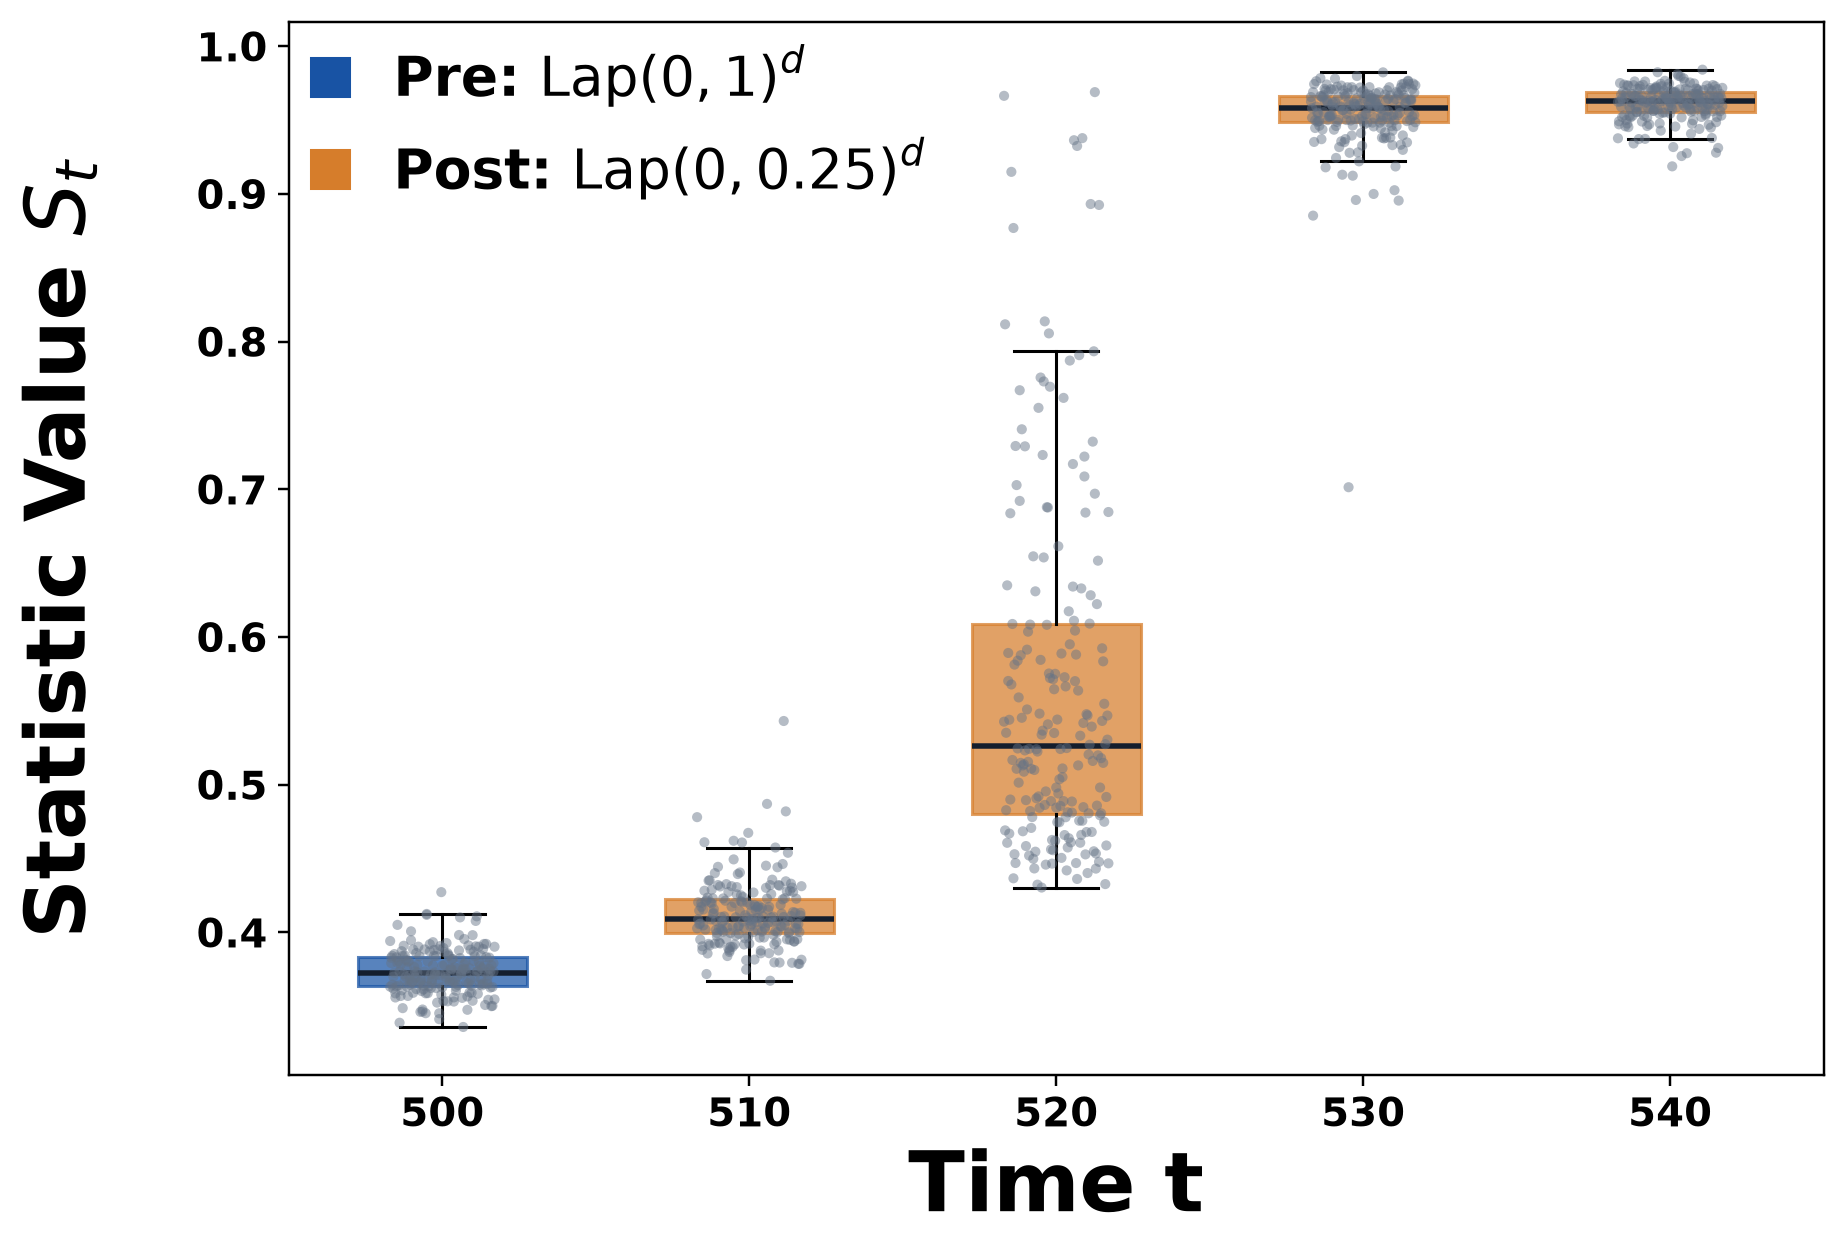

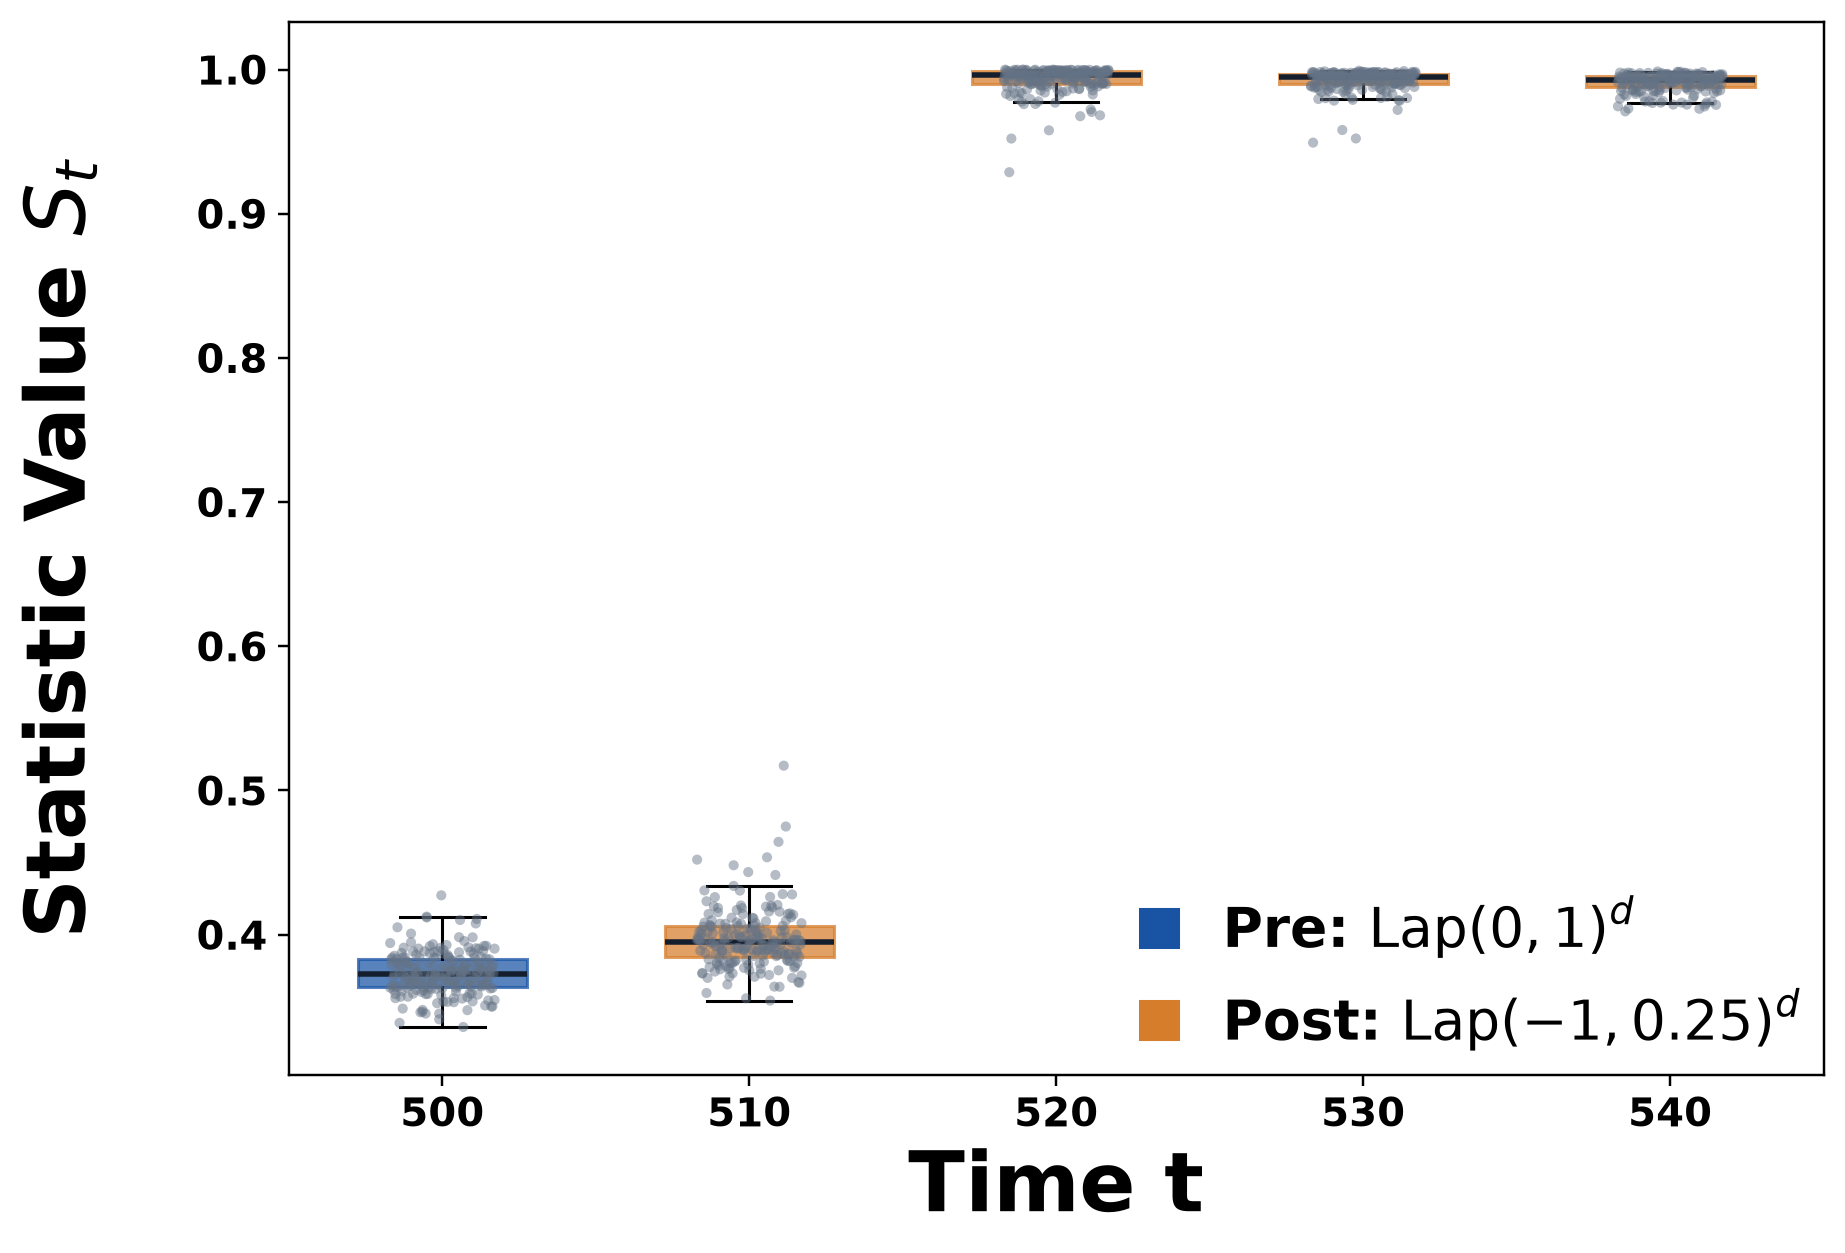

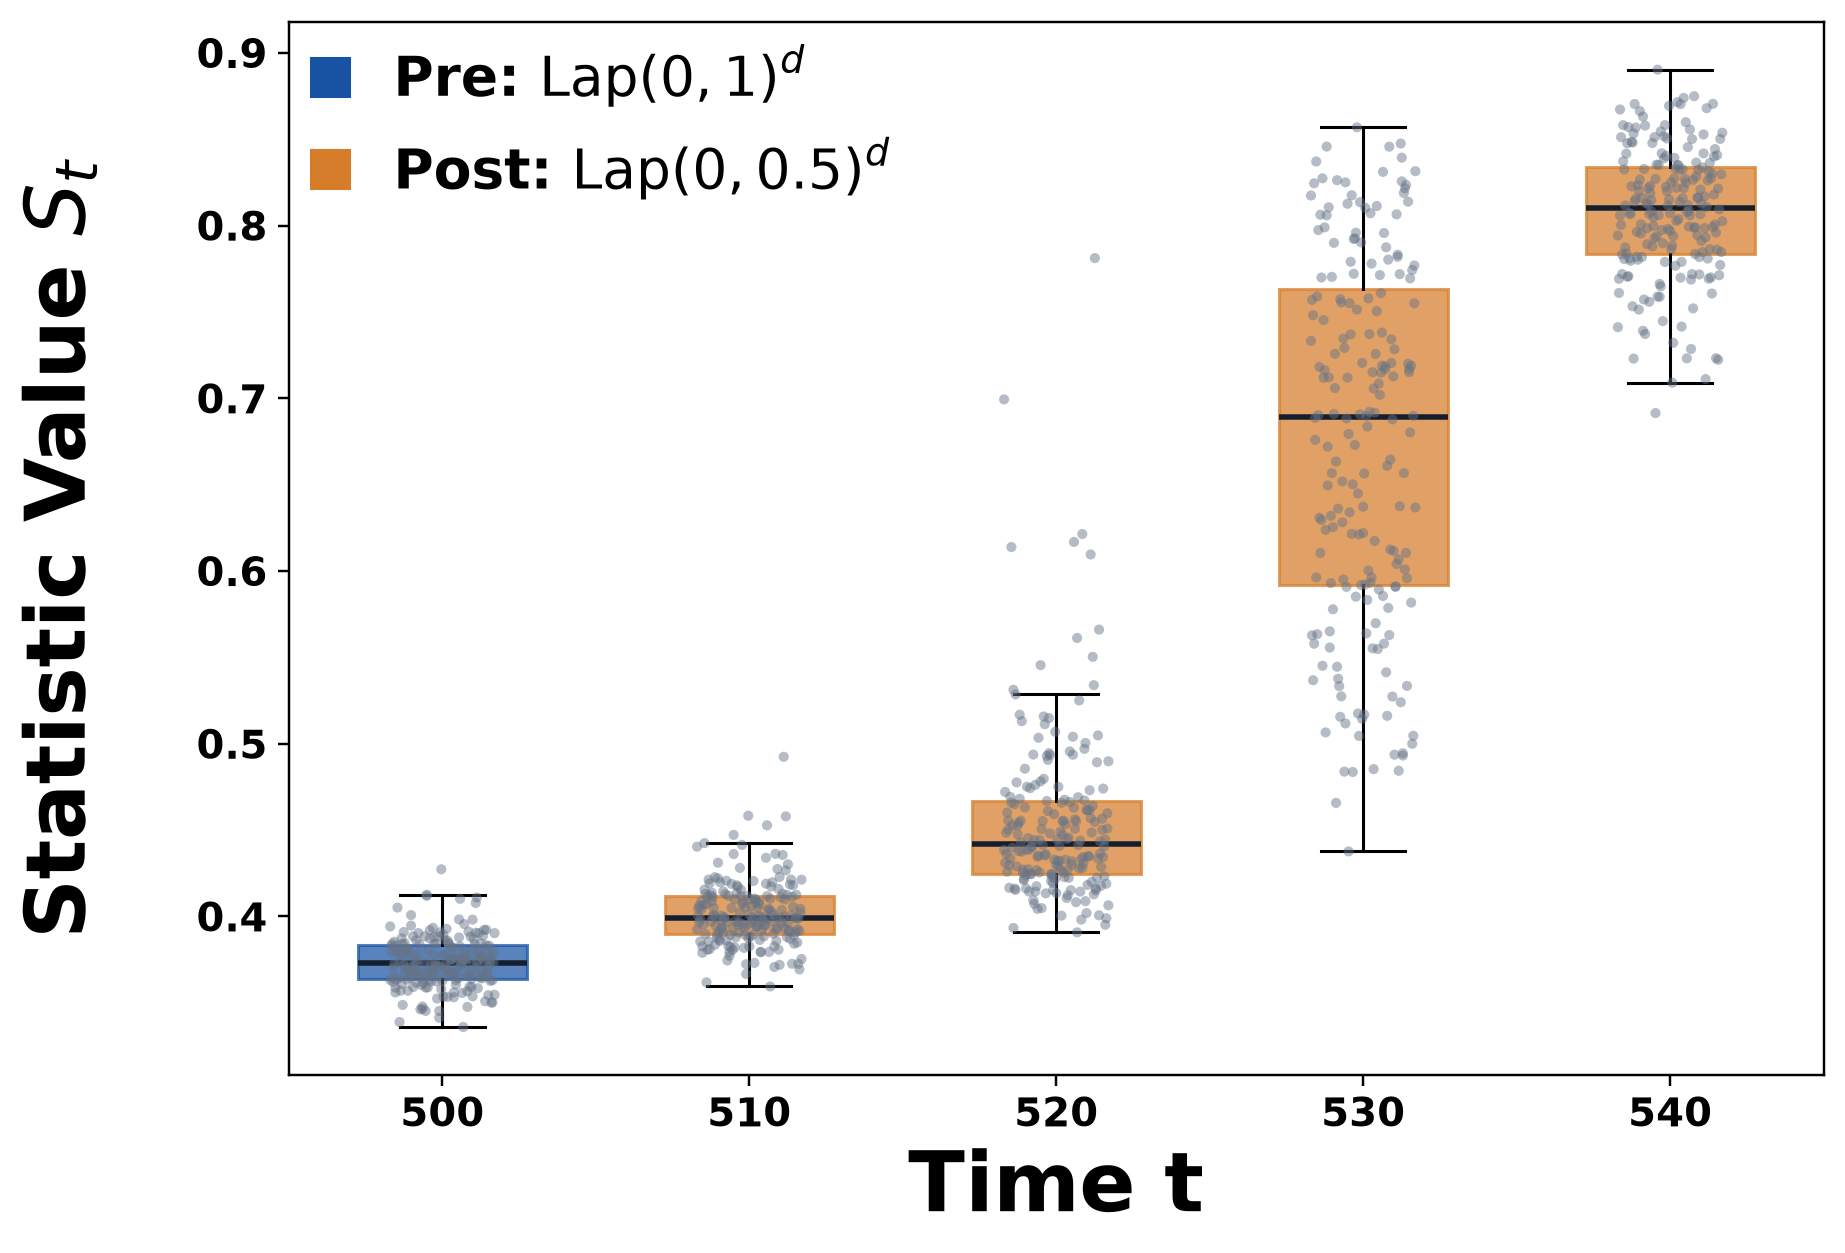

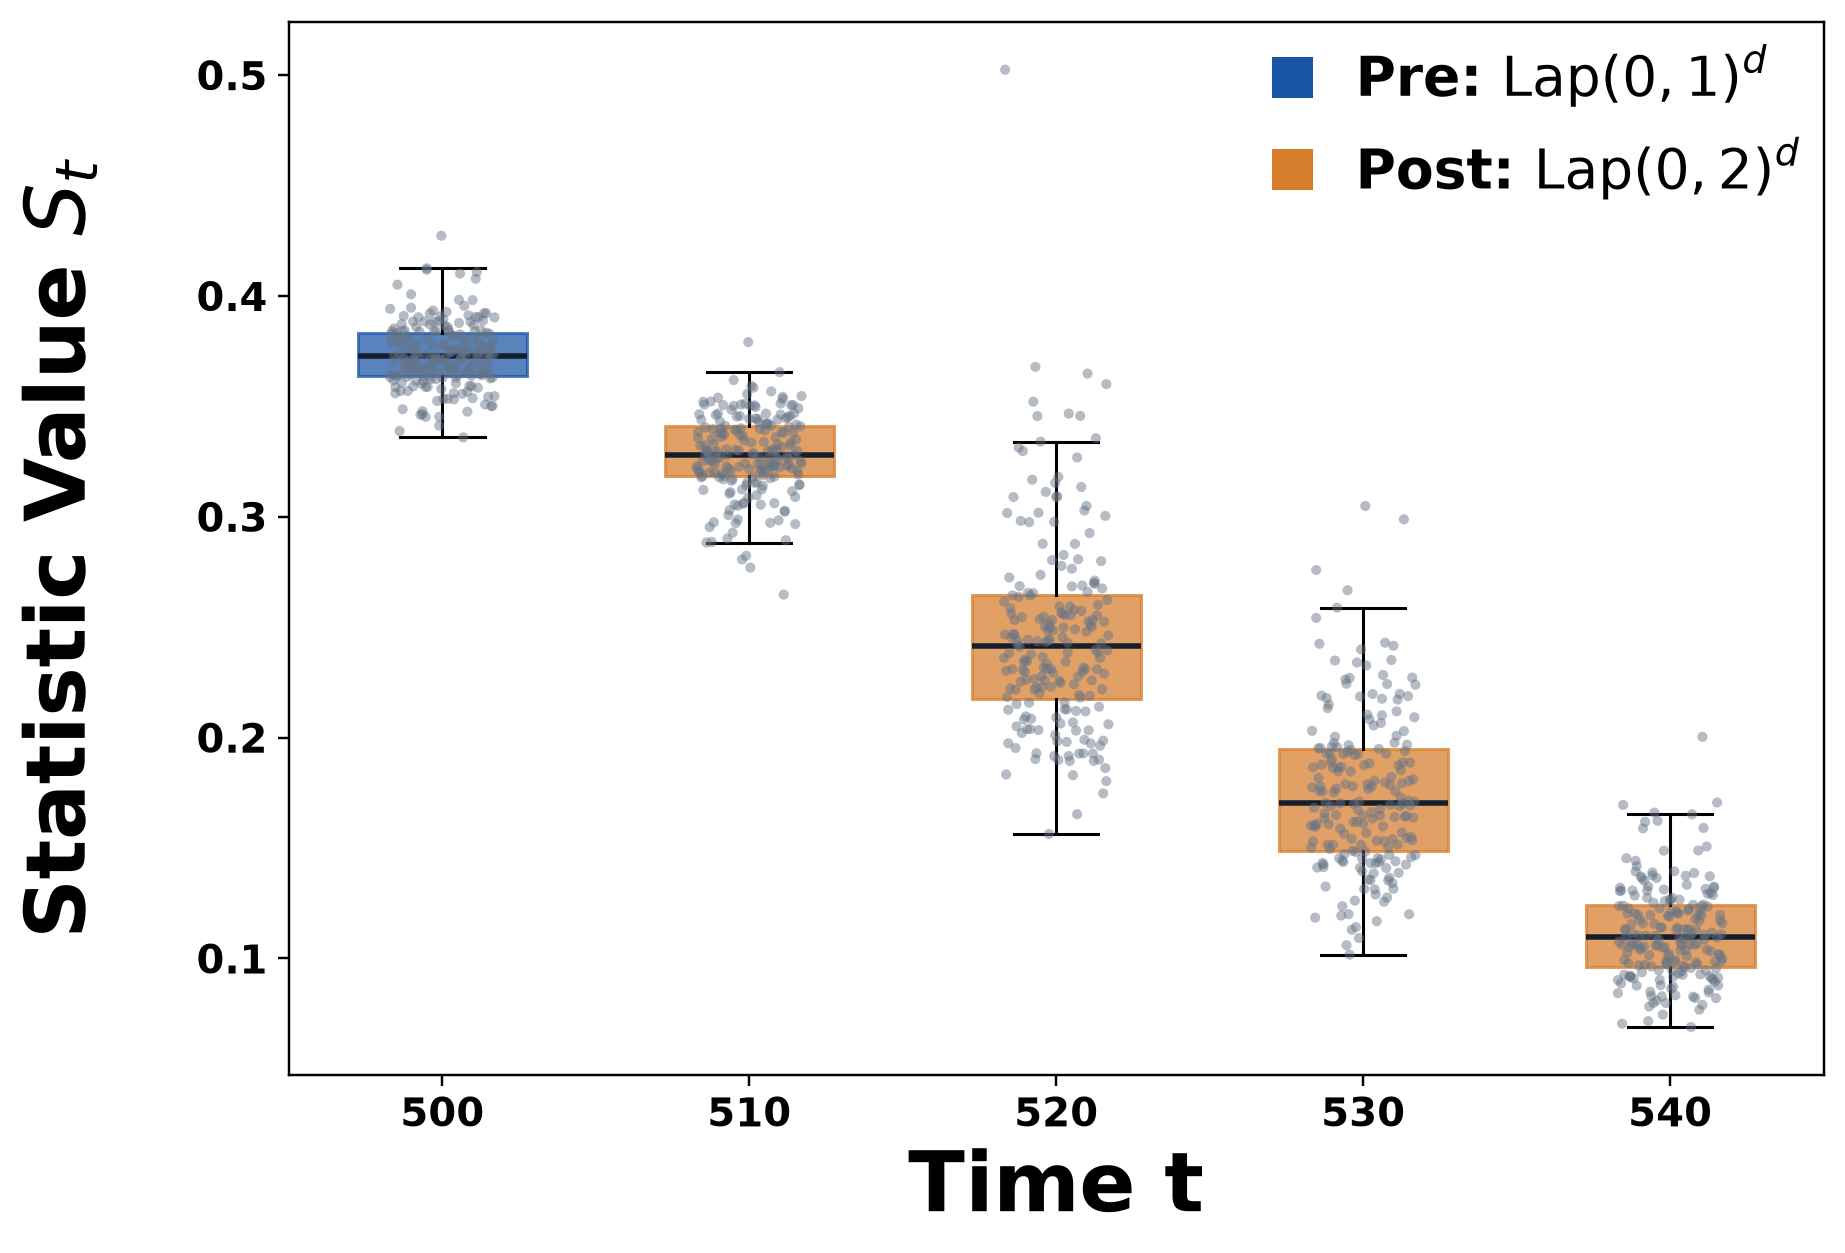

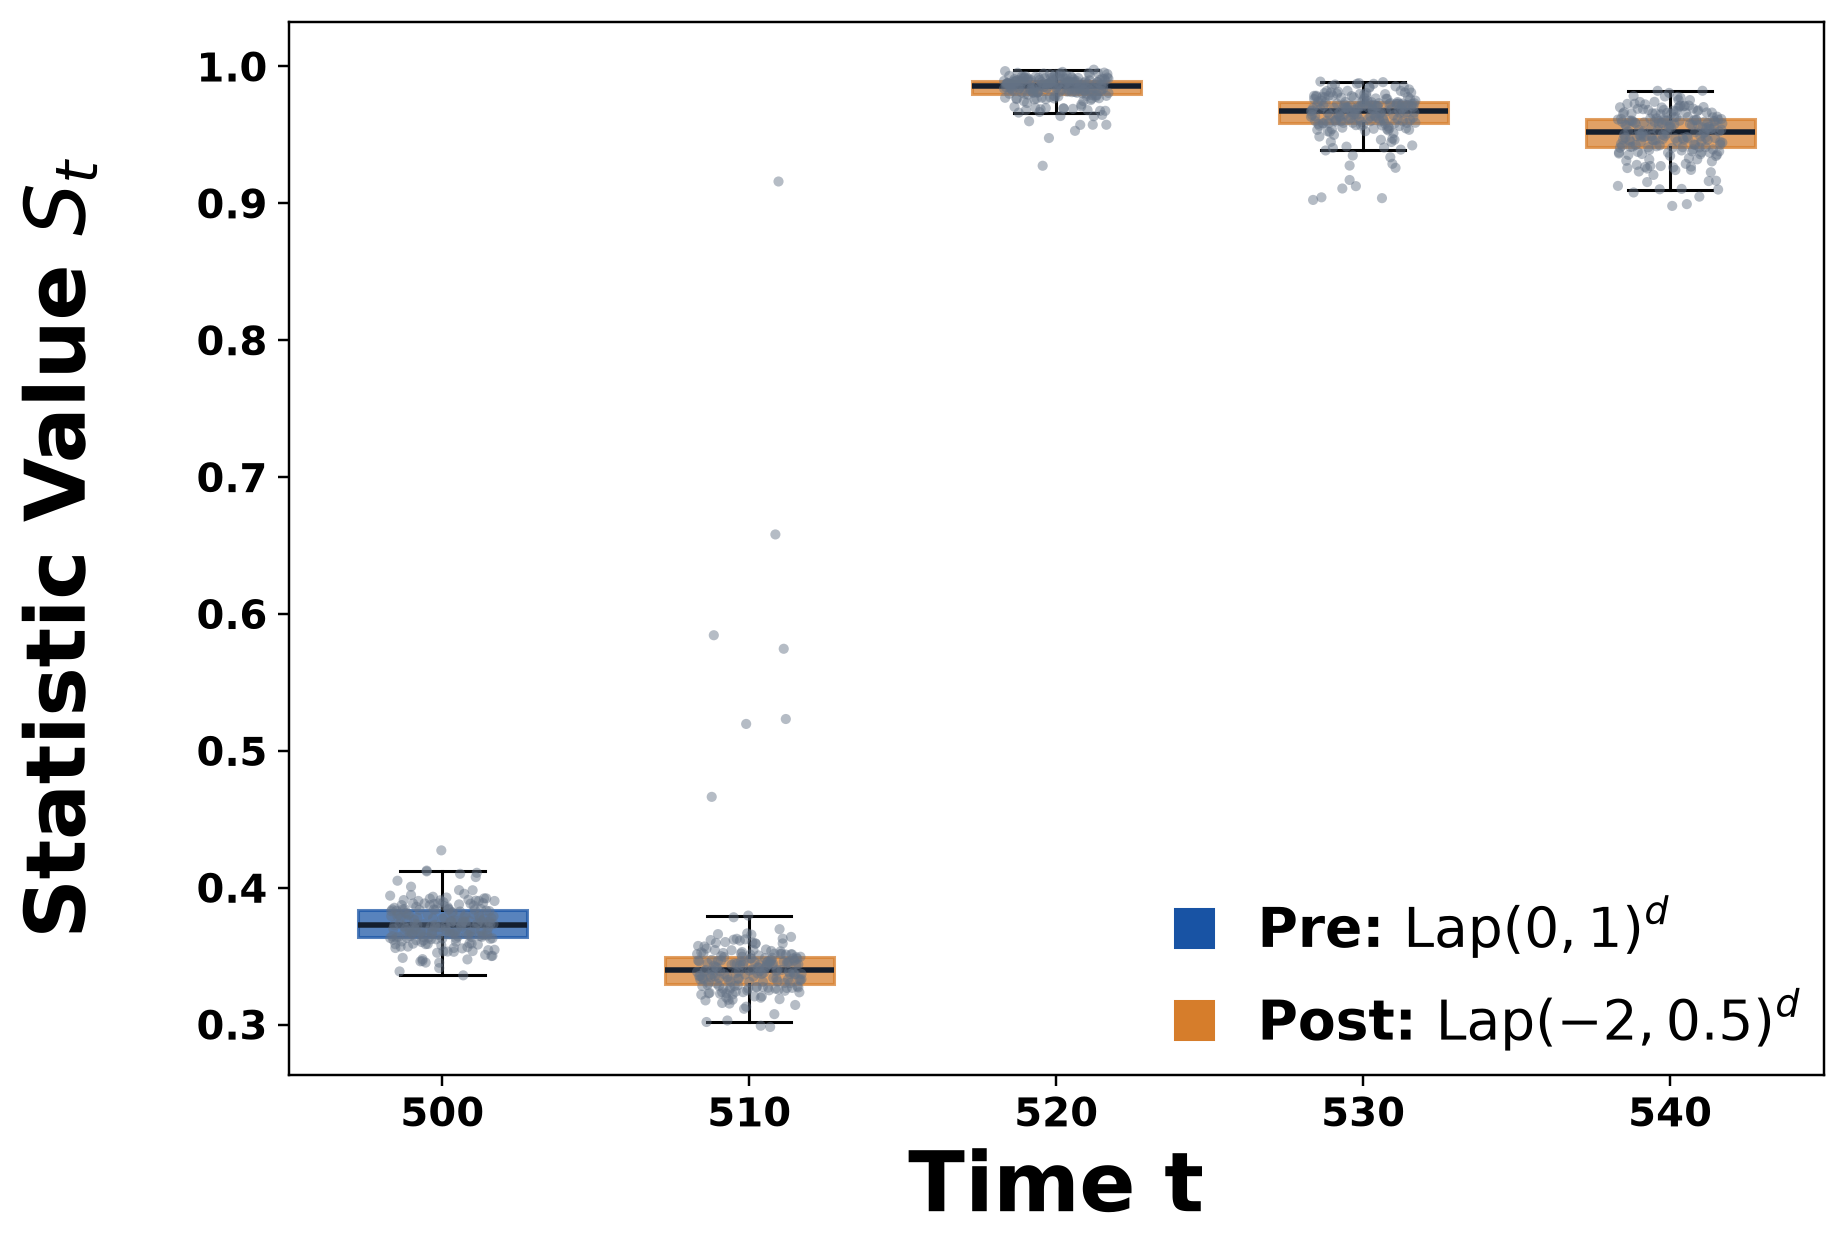

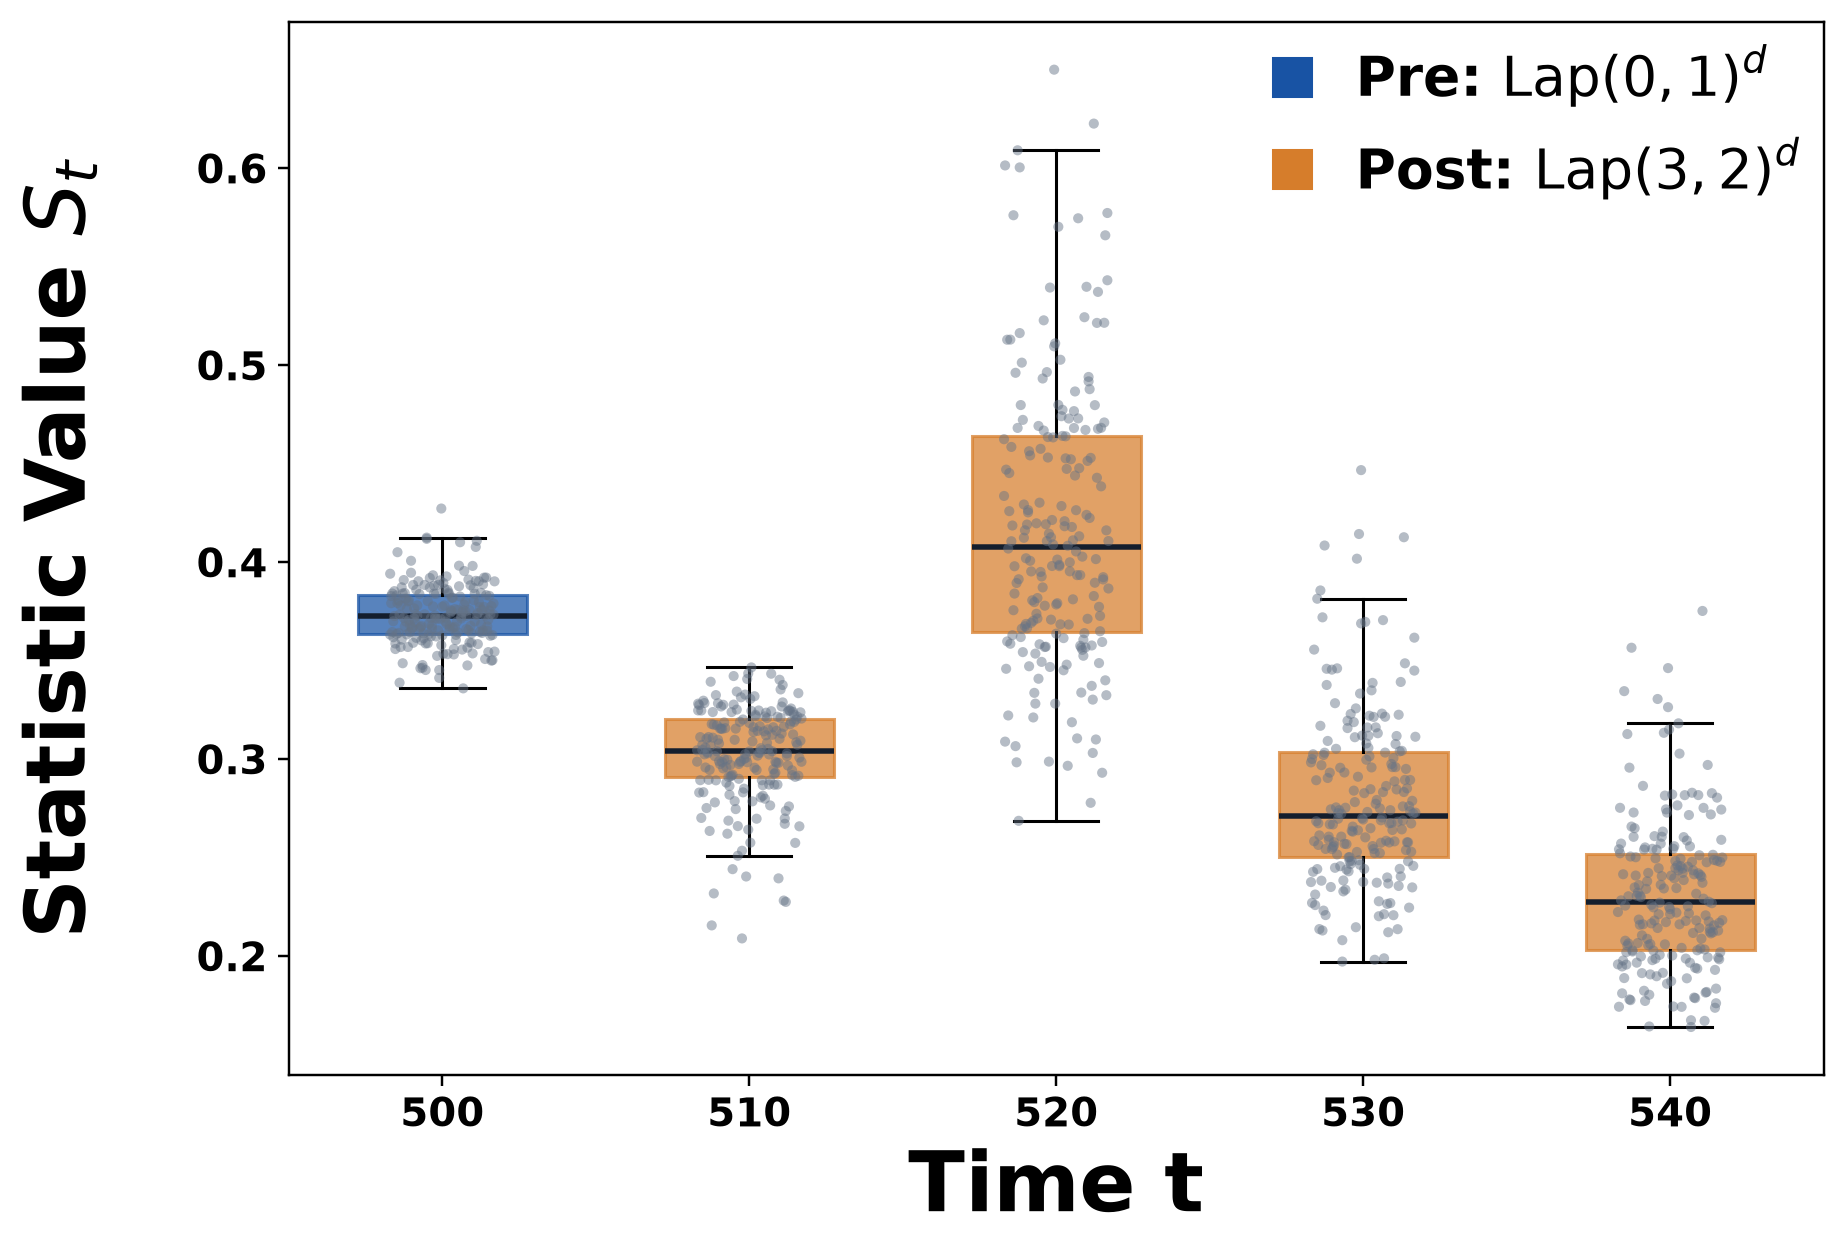

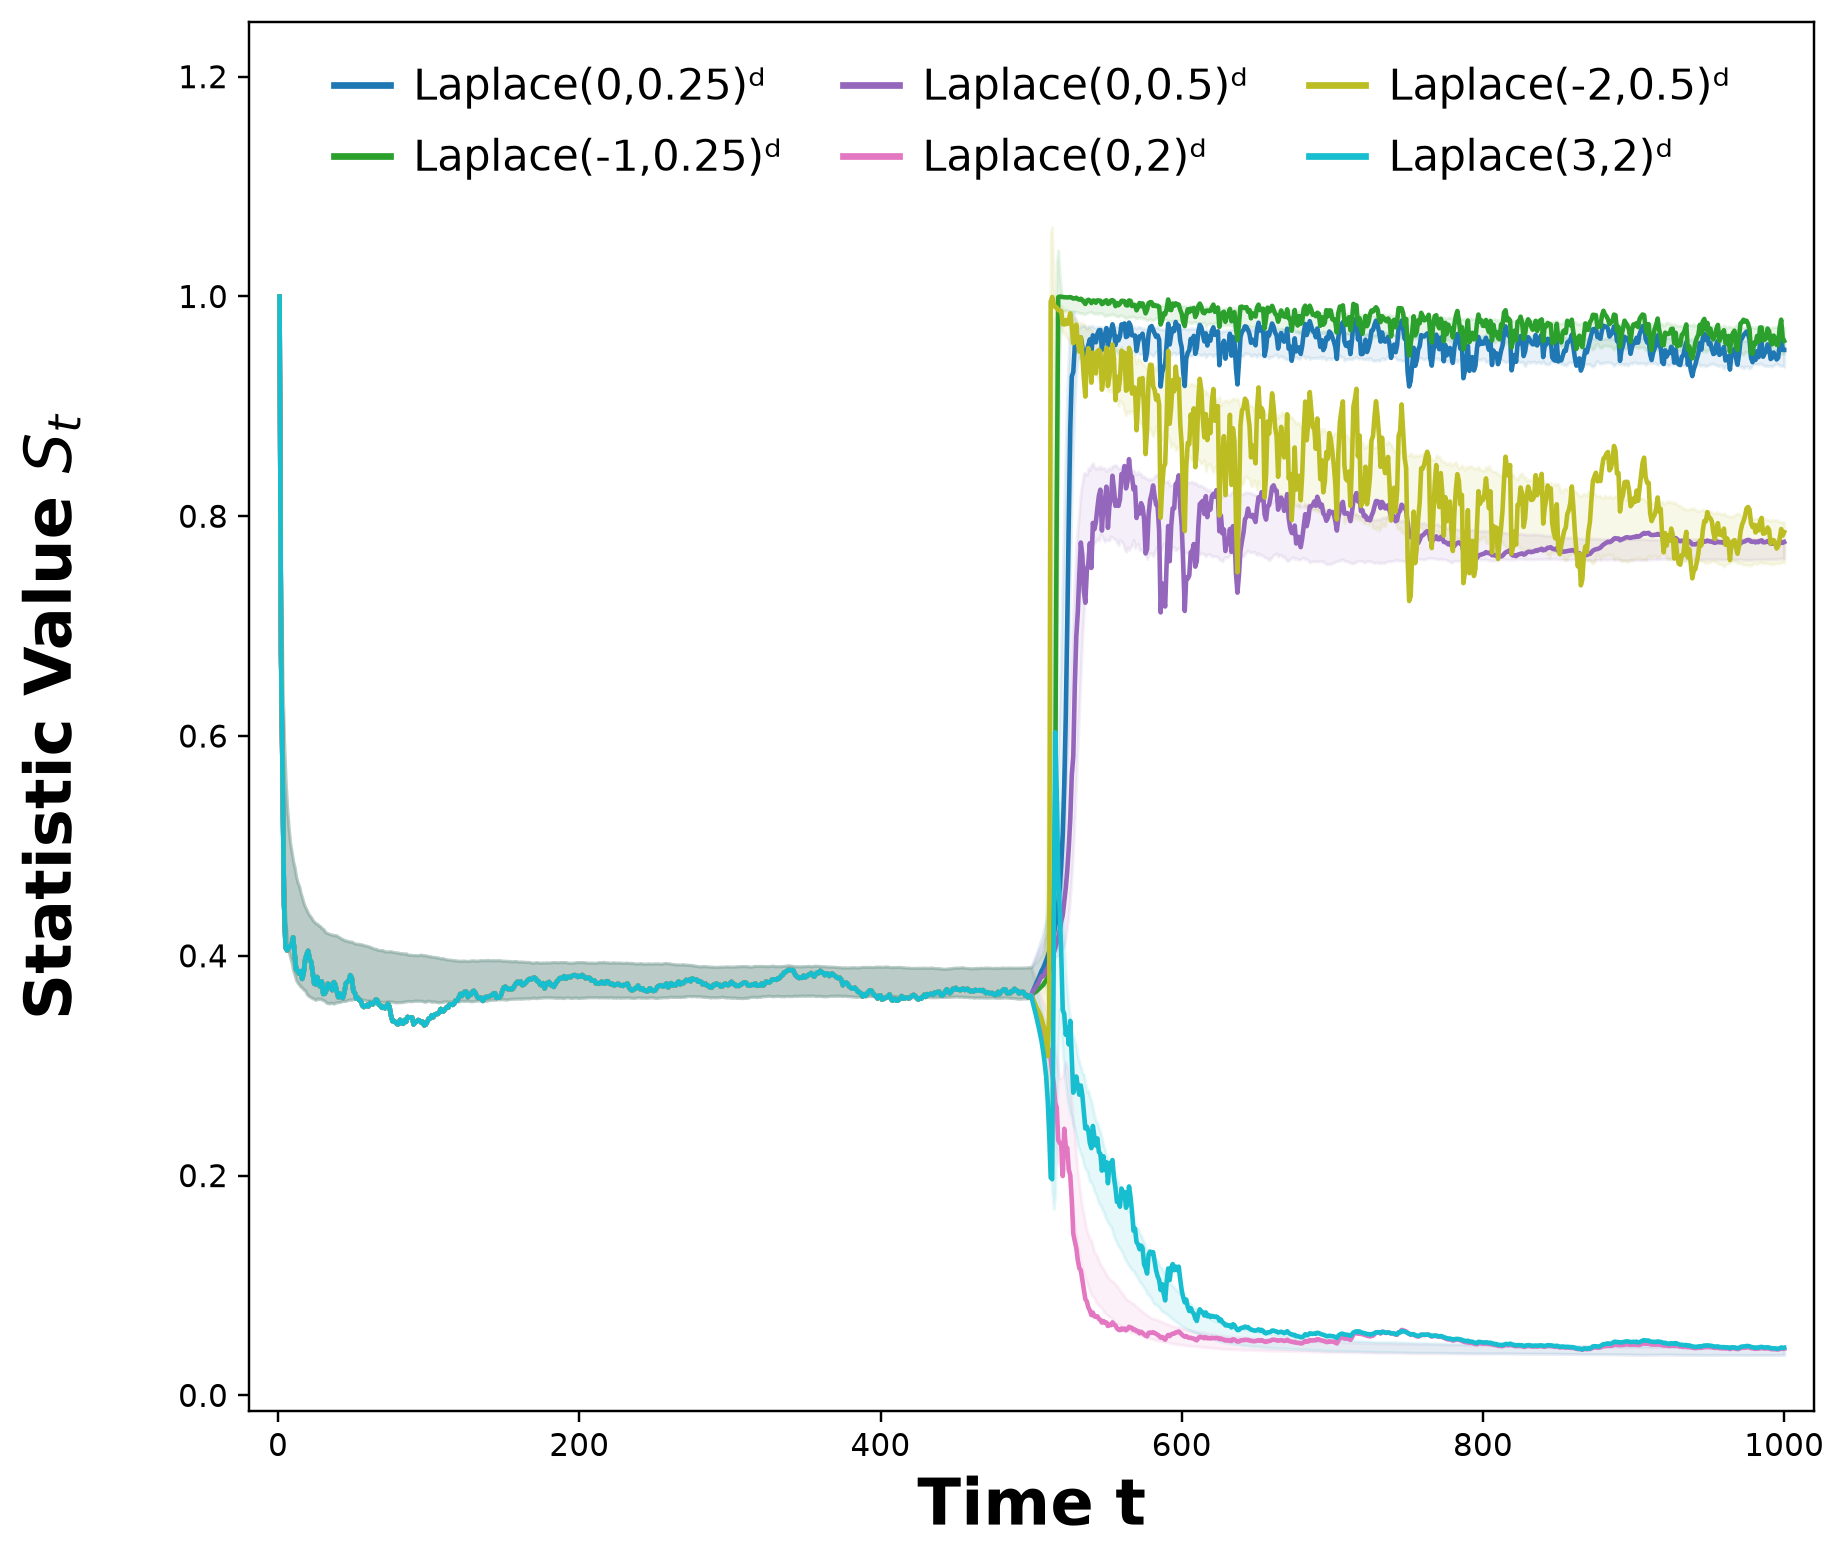

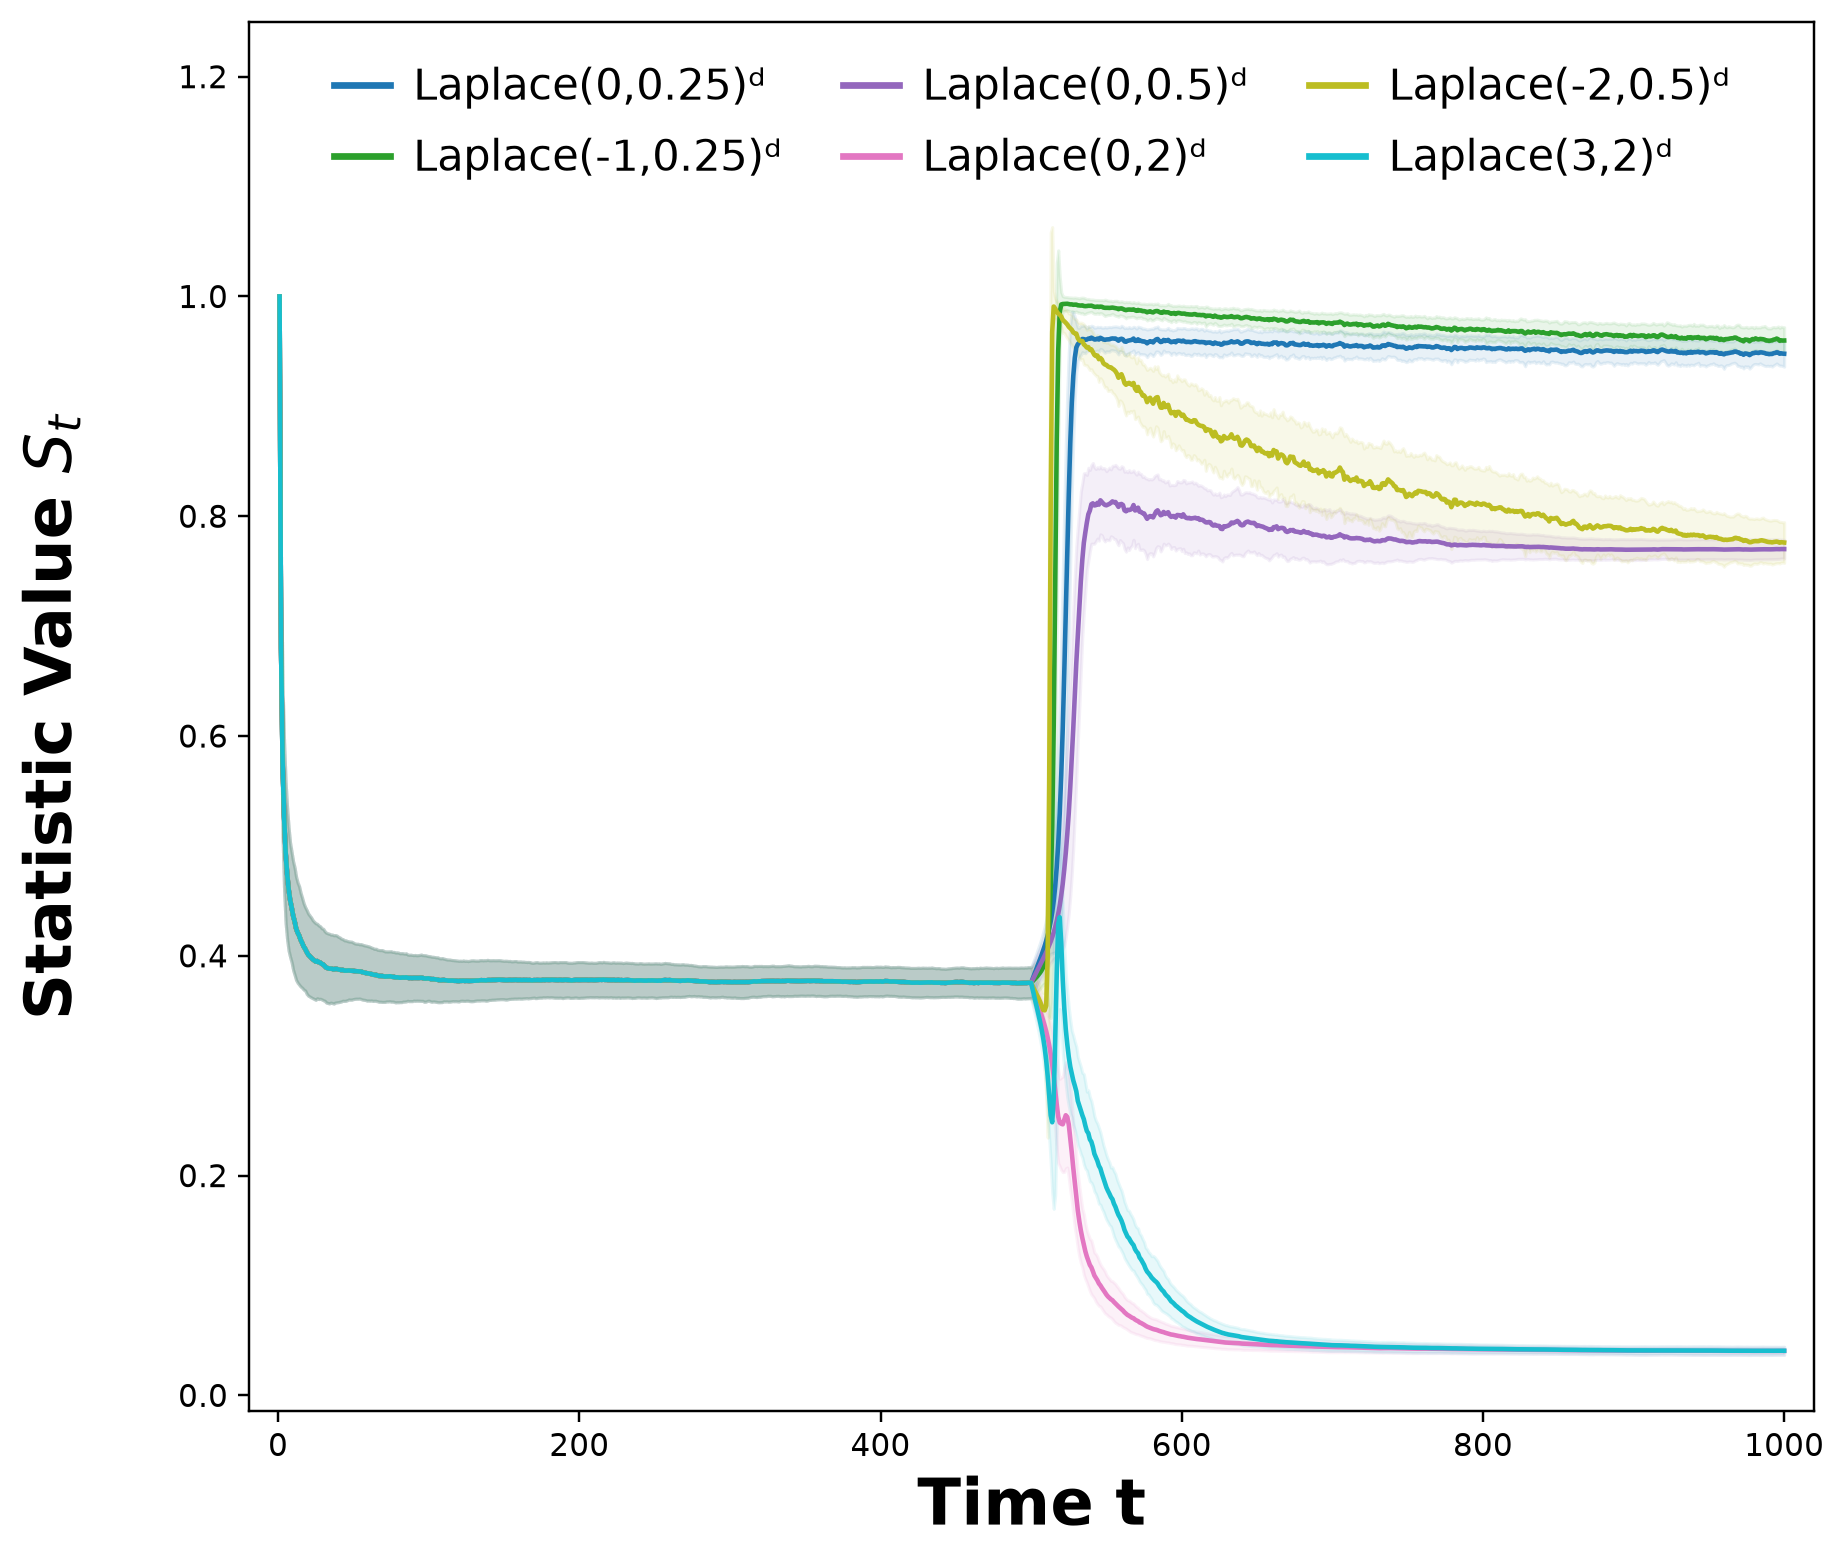

In [5]:
PATH_DIR.mkdir(parents=True, exist_ok=True)
combined_outputs = []
times = np.arange(1, PATH_HORIZON + 1)
colors = plt.cm.tab10(np.linspace(0, 1, max(len(LAPLACE_ALTERNATIVES), 2)))
for series_role in ("path", "mean"):
    fig, ax = plt.subplots(figsize=(8.5, 7.2))
    handles = []
    for color, (case_id, label, *_) in zip(colors, LAPLACE_ALTERNATIVES):
        stats = path_values[case_id]
        mean_path = stats.mean(axis=0)
        std_path = stats.std(axis=0, ddof=1)
        ax.fill_between(times, mean_path - std_path, mean_path + std_path,
                        color=color, alpha=0.10)
        ax.plot(times, mean_path if series_role == "mean" else stats[0],
                color=color, linewidth=1.5)
        handles.append(Line2D([0], [0], color=color, linewidth=2.2, label=label))

    ax.set_xlabel("Time t", fontsize=21, fontweight="bold")
    ax.set_ylabel(r"Statistic Value $S_t$", fontsize=21, fontweight="bold", labelpad=30)
    ax.margins(x=0.02)
    y_bottom, y_top = ax.get_ylim()
    ax.set_ylim(y_bottom, y_top + 0.12 * (y_top - y_bottom))
    ax.grid(False)
    ax.legend(handles=handles, loc="upper center", bbox_to_anchor=(0.5, 0.98),
              ncol=max(1, (len(handles) + 1) // 2), frameon=False, fontsize=14,
              columnspacing=1.45, labelspacing=0.65, handlelength=1.3,
              handletextpad=0.55, borderaxespad=0.0)
    fig.tight_layout()

    suffix = "individual_path_1" if series_role == "path" else "average_paths"
    png = PATH_DIR / f"all_laplace_cases_{suffix}.png"
    pdf = png.with_suffix(".pdf")
    fig.savefig(png, dpi=220, bbox_inches="tight")
    fig.savefig(pdf, bbox_inches="tight")
    plt.close(fig)
    combined_outputs.append(png)
    print(f"Saved {png} and {pdf}")

try:
    from IPython.display import Image, display
    for filename in [*box_outputs, *combined_outputs]:
        display(Image(filename=str(filename)))
except ImportError:
    pass
